# PART 7

Haikal Ali_1103223071_TK46GAB

# Chapter 7 — Matrix Applications


## 1. Matriks Kovarians Data Multivariat

Untuk data multivariat, satu variabel disimpan sebagai satu kolom pada matriks data `X`. Kovarians antara dua variabel adalah dot product dari dua variabel yang sudah di-*mean-center*, lalu dibagi dengan `n-1`.

Jika `X` adalah matriks data yang sudah di-*mean-center*, maka matriks kovarians dapat dihitung dengan:

$$
C = \frac{X^T X}{n-1}
$$

Matriks kovarians selalu berbentuk **features-by-features** dan bersifat simetris.

### Kode dari materi: menghitung matriks kovarians

Di materi, variabel `dataMat` berasal dari dataset. Karena file dataset tidak disertakan dalam PDF, cell berikut membuat `dataMat` contoh agar rumus pada materi dapat langsung dijalankan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from matplotlib import animation
from IPython.display import HTML

np.random.seed(7)

# data contoh: observations x features
n_observations = 250
n_features = 9
latent = np.random.randn(n_observations, 3)
weights = np.random.randn(3, n_features)
dataMat = latent @ weights + 0.5*np.random.randn(n_observations, n_features)

print(dataMat.shape)

(250, 9)


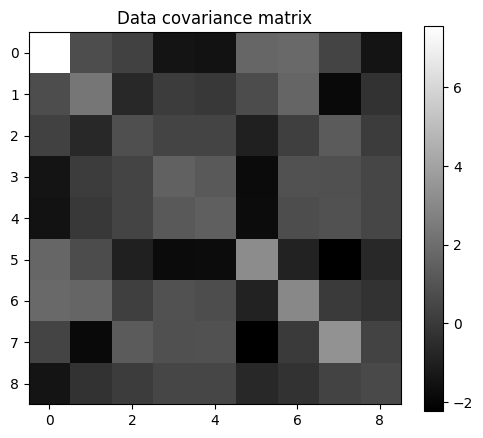

In [2]:
datamean = np.mean(dataMat, axis=0)      # vector of feature means
dataMatM = dataMat - datamean           # mean-center menggunakan broadcasting
covMat = dataMatM.T @ dataMatM          # data matrix times its transpose
covMat /= (dataMatM.shape[0] - 1)        # divide by N-1

plt.figure(figsize=(6, 5))
plt.imshow(covMat, cmap='gray')
plt.title('Data covariance matrix')
plt.colorbar()
plt.show()

## 2. Exercise 7-1 — Korelasi dari Kovarians

Instruksi exercise: ubah matriks kovarians menjadi matriks korelasi menggunakan:

$$
R = SCS
$$

`C` adalah matriks kovarians, sedangkan `S` adalah matriks diagonal yang berisi kebalikan standar deviasi setiap variabel.

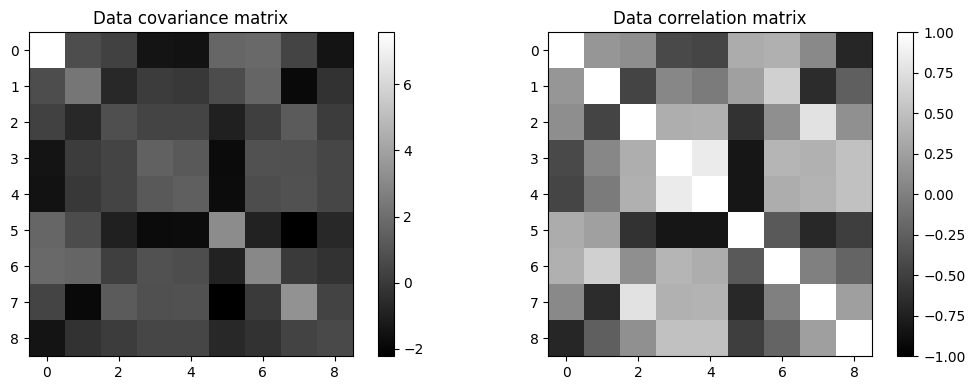

In [3]:
# standar deviasi tiap fitur berasal dari diagonal matriks kovarians
stds = np.sqrt(np.diag(covMat))
S = np.diag(1 / stds)

# correlation matrix dari covariance matrix
corrMat = S @ covMat @ S

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

im0 = axs[0].imshow(covMat, cmap='gray')
axs[0].set_title('Data covariance matrix')
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(corrMat, cmap='gray', vmin=-1, vmax=1)
axs[1].set_title('Data correlation matrix')
plt.colorbar(im1, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 3. Exercise 7-2 — Bandingkan dengan `np.corrcoef()`

Instruksi exercise: gunakan `np.corrcoef()` untuk menghasilkan matriks korelasi, lalu bandingkan dengan hasil manual dari Exercise 7-1.

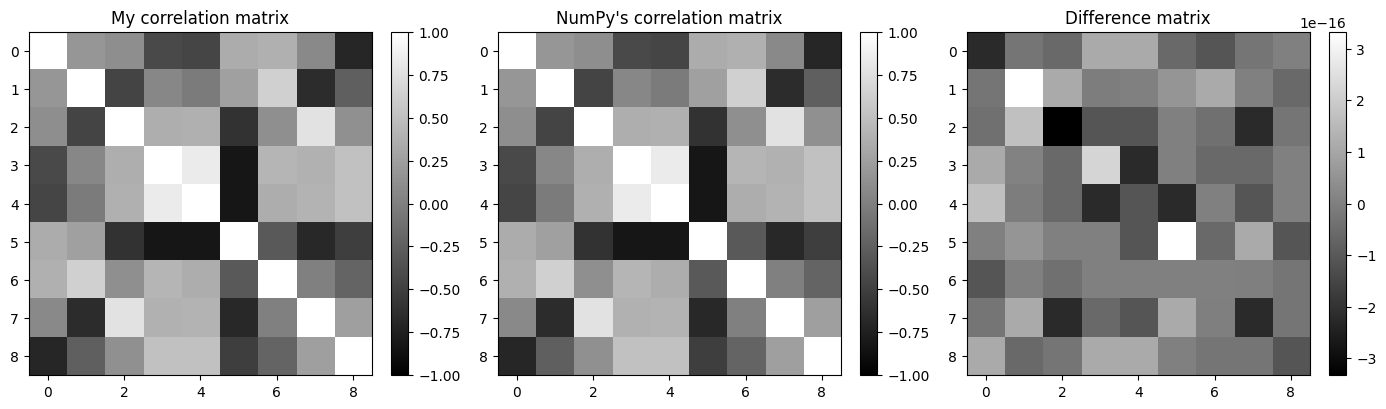

Maksimum selisih absolut: 3.3306690738754696e-16
Apakah sama secara numerik? True


In [4]:
npCorrMat = np.corrcoef(dataMat, rowvar=False)
diffMat = corrMat - npCorrMat

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

im0 = axs[0].imshow(corrMat, cmap='gray', vmin=-1, vmax=1)
axs[0].set_title('My correlation matrix')
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(npCorrMat, cmap='gray', vmin=-1, vmax=1)
axs[1].set_title("NumPy's correlation matrix")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

im2 = axs[2].imshow(diffMat, cmap='gray')
axs[2].set_title('Difference matrix')
plt.colorbar(im2, ax=axs[2], fraction=0.046)

plt.tight_layout()
plt.show()

print('Maksimum selisih absolut:', np.max(np.abs(diffMat)))
print('Apakah sama secara numerik?', np.allclose(corrMat, npCorrMat))

## 4. Transformasi Geometris dengan Perkalian Matriks-Vektor

Perkalian matriks-vektor dapat dipakai untuk melakukan transformasi geometris pada titik koordinat. Matriks rotasi murni 2D adalah:

$$
T = \begin{bmatrix}
\cos\theta & \sin\theta \\
-\sin\theta & \cos\theta
\end{bmatrix}
$$

Matriks ini merotasi titik tanpa mengubah panjangnya.

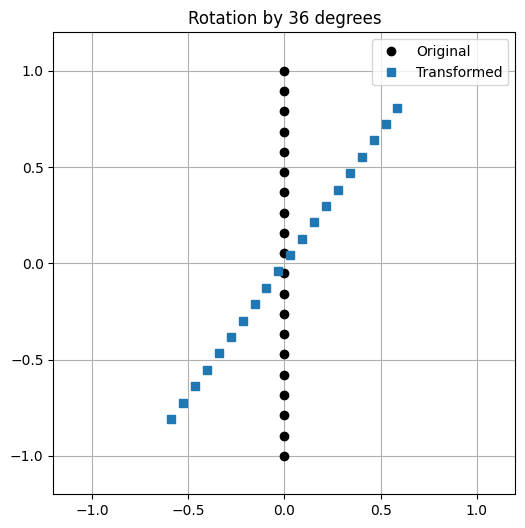

In [5]:
# titik-titik pada garis vertikal
n = 20
points = np.vstack((np.zeros(n), np.linspace(-1, 1, n)))

# rotation matrix
theta = np.pi / 5
T = np.array([
  [np.cos(theta), np.sin(theta)],
  [-np.sin(theta), np.cos(theta)]
])

P = T @ points

plt.figure(figsize=(6, 6))
plt.plot(points[0, :], points[1, :], 'ko', label='Original')
plt.plot(P[0, :], P[1, :], 's', label='Transformed')
plt.axis('square')
plt.xlim([-1.2, 1.2])
plt.ylim([-1.2, 1.2])
plt.grid()
plt.title(f'Rotation by {np.degrees(theta):.0f} degrees')
plt.legend()
plt.show()

## 5. Animasi Transformasi: The Wobbly Circle

Materi menunjukkan animasi dengan titik-titik lingkaran yang ditransformasi oleh matriks:

$$
T = \begin{bmatrix}
1 & 1-\phi \\
0 & 1
\end{bmatrix}
$$

Nilai $\phi$ berubah secara bertahap sehingga bentuk lingkaran ikut berubah.

In [6]:
theta = np.linspace(0, 2*np.pi, 100)
points = np.vstack((np.sin(theta), np.cos(theta)))

fig, ax = plt.subplots(1, figsize=(6, 6))
plth, = ax.plot(points[0, :], points[1, :], 'ko')
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_aspect('equal')
ax.grid()

# fungsi untuk memperbarui frame animasi
def aframe(ph):
  T = np.array([
    [1, 1-ph],
    [0, 1]
  ])
  P = T @ points

  plth.set_xdata(P[0, :])
  plth.set_ydata(P[1, :])
  return plth,

phi = np.linspace(-1, 1-1/40, 40)**2
ani = animation.FuncAnimation(fig, aframe, frames=phi, interval=100, repeat=True)
plt.close(fig)

HTML(ani.to_jshtml())

## 6. Exercise 7-3 — Transformasi Titik pada Lingkaran

Instruksi exercise: tampilkan titik-titik pada lingkaran sebelum dan sesudah transformasi menggunakan matriks:

$$
T = \begin{bmatrix}
1 & .5 \\
0 & .5
\end{bmatrix}
$$

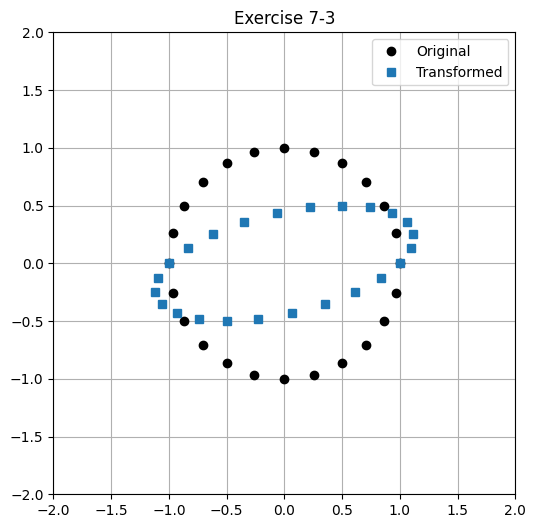

In [7]:
theta = np.linspace(0, 2*np.pi, 24, endpoint=False)
points = np.vstack((np.cos(theta), np.sin(theta)))

T = np.array([
  [1, 0.5],
  [0, 0.5]
])

transformed = T @ points

plt.figure(figsize=(6, 6))
plt.plot(points[0, :], points[1, :], 'ko', label='Original')
plt.plot(transformed[0, :], transformed[1, :], 's', label='Transformed')
plt.axis('square')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.grid()
plt.legend()
plt.title('Exercise 7-3')
plt.show()

## 7. Exercise 7-4 — Animasi The Coiling DNA

Instruksi exercise: buat animasi seperti *The Wobbly Circle*, tetapi gunakan matriks transformasi:

$$
T = \begin{bmatrix}
1-\phi/3 & 0 \\
0 & \phi
\end{bmatrix}, \quad -1 \leq \phi \leq 1
$$

In [8]:
x = np.linspace(0, 4*np.pi, 200)
points1 = np.vstack((x/np.pi, np.sin(x)))
points2 = np.vstack((x/np.pi, np.sin(x + np.pi)))

fig, ax = plt.subplots(1, figsize=(7, 4))
line1, = ax.plot(points1[0, :], points1[1, :], 'k')
line2, = ax.plot(points2[0, :], points2[1, :], color='gray')
ax.set_xlim([-0.5, 4.5])
ax.set_ylim([-2, 2])
ax.grid()

# fungsi frame animasi
def dna_frame(ph):
  T = np.array([
    [1 - ph/3, 0],
    [0, ph]
  ])
  P1 = T @ points1
  P2 = T @ points2

  line1.set_xdata(P1[0, :])
  line1.set_ydata(P1[1, :])
  line2.set_xdata(P2[0, :])
  line2.set_ydata(P2[1, :])
  return line1, line2

phi = np.linspace(-1, 1, 80)
dna_ani = animation.FuncAnimation(fig, dna_frame, frames=phi, interval=80, repeat=True)
plt.close(fig)

HTML(dna_ani.to_jshtml())

## 8. Deteksi Fitur Gambar

Image filtering adalah perluasan dari filtering time series ke 2D. Kernel 2D digeser di atas gambar, lalu setiap posisi menghasilkan nilai dari perkalian Hadamard dan penjumlahan semua elemen.

Kernel Gaussian 2D dari materi:

$$
G = \exp(-(X^2 + Y^2)/\sigma)
$$

Kernel dinormalisasi agar jumlah seluruh elemennya sama dengan 1.

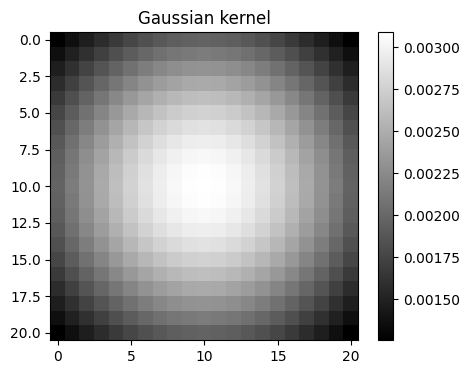

In [9]:
Y, X = np.meshgrid(np.linspace(-3, 3, 21), np.linspace(-3, 3, 21))
kernel = np.exp(-(X**2 + Y**2) / 20)
kernel = kernel / np.sum(kernel) # normalize

plt.figure(figsize=(5, 4))
plt.imshow(kernel, cmap='gray')
plt.title('Gaussian kernel')
plt.colorbar()
plt.show()

### Kode dari materi: konvolusi gambar dengan double for loop

Kode berikut mengikuti mekanisme pada materi: ambil potongan gambar, kalikan Hadamard dengan kernel, lalu jumlahkan.

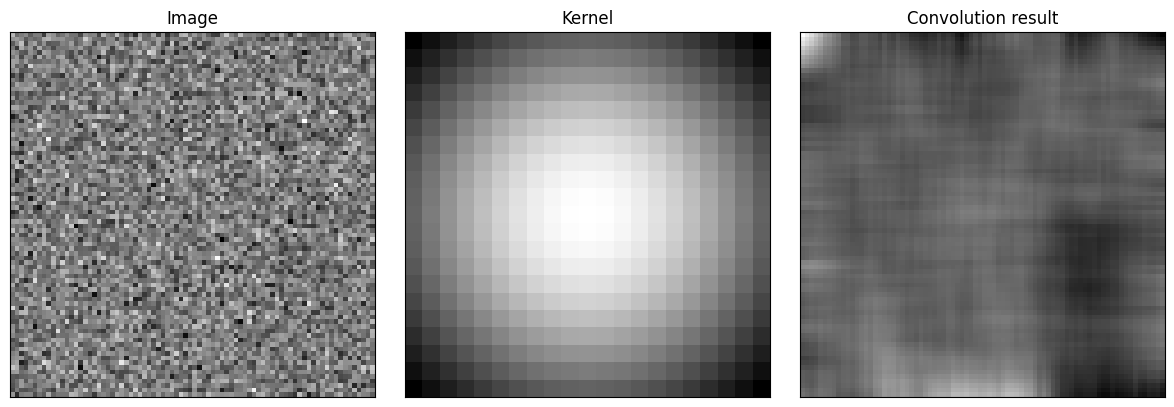

In [10]:
np.random.seed(7)
imgN = 80
image = np.random.randn(imgN, imgN)

halfKr = kernel.shape[0] // 2
imagePad = np.pad(image, pad_width=halfKr, mode='edge')
convoutput = np.zeros_like(imagePad)

for rowi in range(halfKr, imgN+halfKr):
  for coli in range(halfKr, imgN+halfKr):
    # cut out a piece of the image
    pieceOfImg = imagePad[rowi-halfKr:rowi+halfKr+1:1,
                          coli-halfKr:coli+halfKr+1:1]

    # dot product: Hadamard multiply and sum
    dotprod = np.sum(pieceOfImg * kernel)

    # store the result for this pixel
    convoutput[rowi, coli] = dotprod

convoutput = convoutput[halfKr:-halfKr, halfKr:-halfKr]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Image')
axs[1].imshow(kernel, cmap='gray')
axs[1].set_title('Kernel')
axs[2].imshow(convoutput, cmap='gray')
axs[2].set_title('Convolution result')
for ax in axs:
  ax.set_xticks([])
  ax.set_yticks([])
plt.tight_layout()
plt.show()

## 9. Exercise 7-5 — Smooth gambar 3D

Instruksi exercise: smooth gambar 3D dengan menerapkan smoothing pada masing-masing channel warna secara terpisah. Hasil `convolve2d` bertipe `float64`, sehingga perlu dikonversi ke `uint8` agar dapat ditampilkan dengan benar.

PDF tidak menyertakan file gambar asli sebagai file terpisah. Cell berikut akan memakai `bathtub.png` jika tersedia di folder kerja. Jika tidak ada, dibuat matriks gambar RGB contoh agar prosedur smoothing tetap dapat dijalankan.

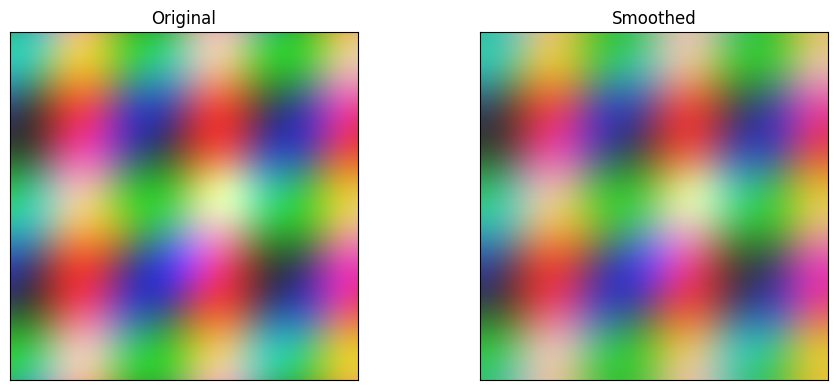

dtype hasil: uint8


In [11]:
from pathlib import Path

# helper untuk membuat gambar RGB contoh jika file gambar asli tidak tersedia
def make_rgb_example(n=240):
  y, x = np.mgrid[-1:1:complex(0, n), -1:1:complex(0, n)]
  img = np.zeros((n, n, 3), dtype=float)
  img[:, :, 0] = 0.55 + 0.35*np.sin(8*x) + 0.15*np.exp(-((x+.35)**2 + (y-.15)**2)/0.03)
  img[:, :, 1] = 0.50 + 0.30*np.cos(7*y) + 0.20*np.exp(-((x-.25)**2 + (y+.10)**2)/0.04)
  img[:, :, 2] = 0.45 + 0.25*np.sin(6*(x+y)) + 0.25*np.exp(-((x-.05)**2 + (y-.35)**2)/0.05)
  img = np.clip(img, 0, 1)
  return (img * 255).astype(np.uint8)

img_path = Path('bathtub.png')
if img_path.exists():
  rgb_img = plt.imread(img_path)
  if rgb_img.dtype != np.uint8:
    rgb_img = (255*np.clip(rgb_img[:, :, :3], 0, 1)).astype(np.uint8)
  else:
    rgb_img = rgb_img[:, :, :3]
else:
  rgb_img = make_rgb_example()

# smoothing kernel
Y, X = np.meshgrid(np.linspace(-3, 3, 31), np.linspace(-3, 3, 31))
gkernel = np.exp(-(X**2 + Y**2) / 5)
gkernel = gkernel / np.sum(gkernel)

smooth_rgb = np.zeros_like(rgb_img, dtype=float)
for ch in range(3):
  smooth_rgb[:, :, ch] = convolve2d(rgb_img[:, :, ch], gkernel, mode='same', boundary='symm')

smooth_rgb = np.clip(smooth_rgb, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(rgb_img)
axs[0].set_title('Original')
axs[1].imshow(smooth_rgb)
axs[1].set_title('Smoothed')
for ax in axs:
  ax.set_xticks([])
  ax.set_yticks([])
plt.tight_layout()
plt.show()

print('dtype hasil:', smooth_rgb.dtype)

## 10. Exercise 7-6 — Kernel berbeda untuk tiap channel warna

Instruksi exercise: gunakan width Gaussian berbeda untuk tiap channel: `0.5` untuk R, `5` untuk G, dan `50` untuk B.

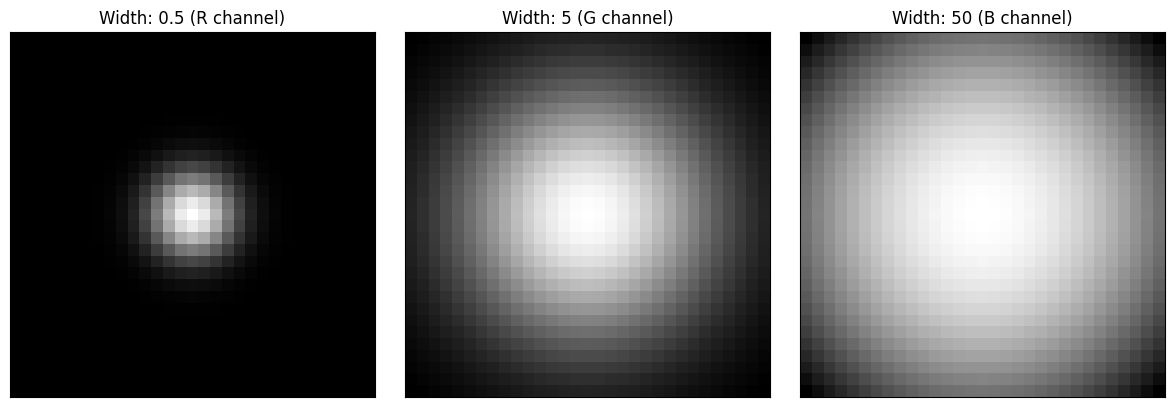

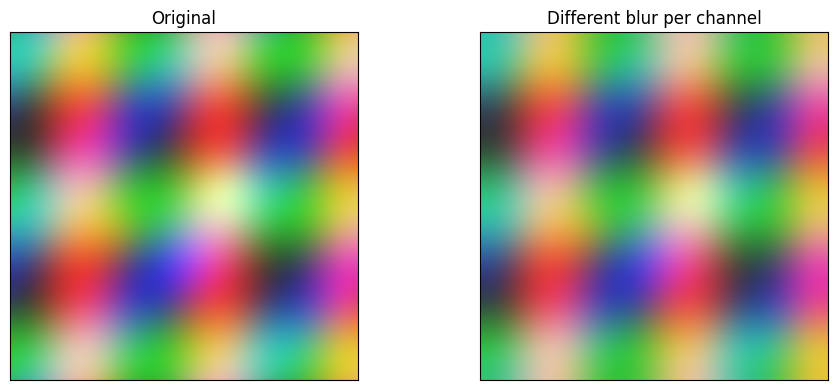

In [12]:
def gaussian_kernel(width, size=31):
  Y, X = np.meshgrid(np.linspace(-3, 3, size), np.linspace(-3, 3, size))
  kernel = np.exp(-(X**2 + Y**2) / width)
  return kernel / np.sum(kernel)

widths = [0.5, 5, 50]
channel_names = ['R channel', 'G channel', 'B channel']
kernels = [gaussian_kernel(w, size=31) for w in widths]

channel_smooth = np.zeros_like(rgb_img, dtype=float)
for ch in range(3):
  channel_smooth[:, :, ch] = convolve2d(rgb_img[:, :, ch], kernels[ch], mode='same', boundary='symm')

channel_smooth = np.clip(channel_smooth, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ch in range(3):
  axs[ch].imshow(kernels[ch], cmap='gray')
  axs[ch].set_title(f'Width: {widths[ch]} ({channel_names[ch]})')
  axs[ch].set_xticks([])
  axs[ch].set_yticks([])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(rgb_img)
axs[0].set_title('Original')
axs[1].imshow(channel_smooth)
axs[1].set_title('Different blur per channel')
for ax in axs:
  ax.set_xticks([])
  ax.set_yticks([])
plt.tight_layout()
plt.show()

## 11. Exercise 7-7 — Deteksi garis horizontal dan vertikal

Instruksi exercise: buat dua kernel 3×3 yang berisi `-1`, `0`, dan `+1` untuk mendeteksi garis vertikal dan horizontal, lalu konvolusikan dengan gambar grayscale 2D.

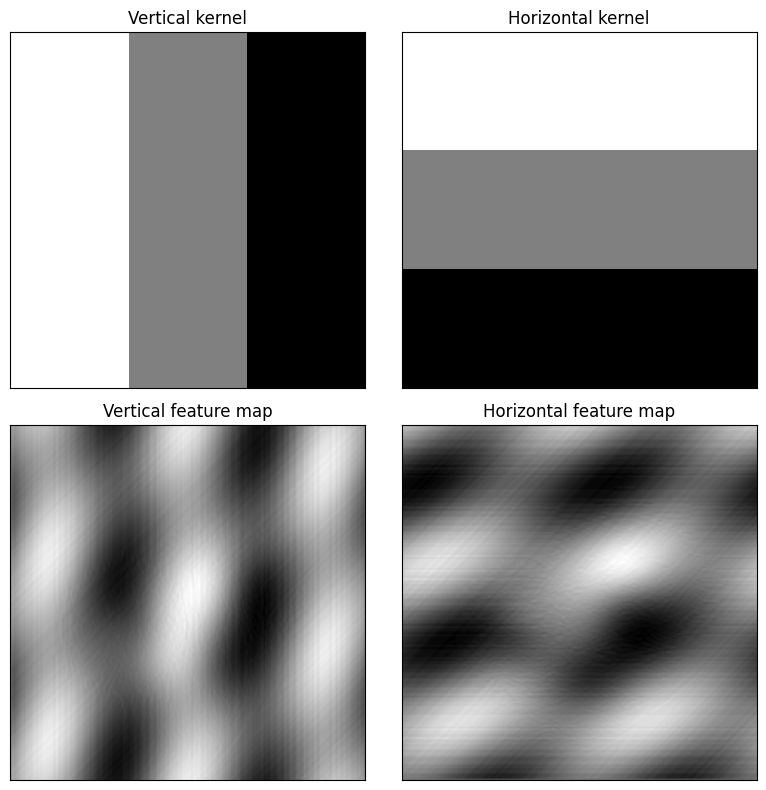

In [13]:
gray_img = np.mean(rgb_img, axis=2)

vertical_kernel = np.array([
  [1, 0, -1],
  [1, 0, -1],
  [1, 0, -1]
])

horizontal_kernel = np.array([
  [1, 1, 1],
  [0, 0, 0],
  [-1, -1, -1]
])

vertical_features = convolve2d(gray_img, vertical_kernel, mode='same', boundary='symm')
horizontal_features = convolve2d(gray_img, horizontal_kernel, mode='same', boundary='symm')

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs[0, 0].imshow(vertical_kernel, cmap='gray')
axs[0, 0].set_title('Vertical kernel')
axs[0, 1].imshow(horizontal_kernel, cmap='gray')
axs[0, 1].set_title('Horizontal kernel')
axs[1, 0].imshow(vertical_features, cmap='gray')
axs[1, 0].set_title('Vertical feature map')
axs[1, 1].imshow(horizontal_features, cmap='gray')
axs[1, 1].set_title('Horizontal feature map')

for ax in axs.ravel():
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

## Ringkasan

Bab ini menunjukkan tiga aplikasi utama matriks:

1. Matriks kovarians dan korelasi dapat dihitung melalui perkalian matriks.
2. Transformasi geometris dapat dilakukan dengan perkalian matriks-vektor.
3. Filtering gambar memakai prinsip perkalian elemen-wise dan penjumlahan, mirip dot product pada sinyal 1D.